In [25]:
import ee
import geemap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Name of project in google cloud available to use with Earth Engine
EE_PROJECT = "ee-gis-scode"

try:
    if EE_PROJECT:
        ee.Initialize(project=EE_PROJECT)
    else:
        ee.Initialize()
except Exception as e:
    raise RuntimeError(
        "Failed to initialize the Earth Engine client. "
        "Make sure you have authenticated by running 'earthengine authenticate' "
        "in your command line. "
        "If you have already authenticated, ensure that the EE_PROJECT variable is set correctly."
    ) from e

In [13]:
# --- 1. Definir Área de Interés (AOI) ---
# Usaremos las coordenadas de Cuenca.
# Recommendation: Para un análisis más preciso, podrías cargar un shapefile.
xmin, ymin = -79.350128,-2.992413
xmax, ymax = -78.932648,-2.720840
cuenca_aoi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

# --- 2. Cargar el Dataset de Hansen Global Forest Change ---
# hansen_dataser: Proporciona un mapa ráster (una imagen, no un shapefile) donde cada píxel 
# indica el año en que se perdió la cobertura forestal.
# Se le pides a GEE que dé acceso a todo el dataset.
hansen_dataset = ee.Image("UMD/hansen/global_forest_change_2024_v1_12")
print("Dataset de Hansen cargado.")

Dataset de Hansen cargado.


In [14]:
# --- 3. Seleccionar las Bandas de Interés ---
# Extraemos las dos "capas" que nos importan de la super-imagen.
#treecover2000: Una capa que muestra el porcentaje de cobertura de árboles en el año 2000. La usaremos para definir dónde había bosque originalmente.
#lossyear: Una capa donde el valor de cada píxel indica el año en que se perdió el bosque (si es que se perdió). Un valor de 23 significa que la pérdida ocurrió en 2023.
tree_cover_2000 = hansen_dataset.select(['treecover2000'])
loss_year = hansen_dataset.select(['lossyear'])
gain = hansen_dataset.select(['gain']) # También consideraremos la ganancia de bosque

In [15]:
# CLASE 2: DEFORESTADO (Deforestación en 2024)
# La lógica aquí es correcta. Los píxeles deben tener el valor del año de pérdida.
deforested_mask = loss_year.eq(24)

In [16]:
# CLASE 1: BOSQUE ESTABLE (Lógica Flexible)
# Un píxel es "Bosque" si:
# a) Tenía más de 30% de cobertura en el año 2000.
# b) Y... NO se ha perdido hasta ahora (loss_year es 0) O si ha ganado cobertura (gain es 1).
# Esto captura bosques primarios y bosques en recuperación.
forest_mask = tree_cover_2000.gte(10).And(gain.eq(1))

In [17]:

# --- 3. Crear la Imagen de Etiquetas Unificada ---
# Este es el paso más importante para el entrenamiento del modelo.

# Empezamos con una imagen donde todo es 0 (Clase 0: Otras Tierras)
label_image = ee.Image(0).clip(cuenca_aoi)

# "Pintamos" los píxeles de bosque con el valor 1
label_image = label_image.where(forest_mask, 1)

# "Pintamos" los píxeles deforestados con el valor 2.
# Esta línea sobreescribe los píxeles de bosque que fueron deforestados en 2024.
label_image = label_image.where(deforested_mask, 2)

# --- 4. Visualización para Verificación ---
Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)
Map.setOptions('HYBRID')

# Paleta de colores para las clases: 0 (Gris), 1 (Verde), 2 (Rojo)
label_palette = ['#AAAAAA', '#008000', '#FF0000']

Map.addLayer(label_image, {'min': 0, 'max': 2, 'palette': label_palette}, 'Mapa de Etiquetas para Entrenamiento')

Map.add_legend(title="Leyenda de Clases", legend_dict={
    "Otras Tierras (Clase 0)": "#AAAAAA",
    "Bosque (Clase 1)": "#008000",
    "Deforestado 2024 (Clase 2)": "#FF0000"
})

display(Map)

Map(center=[-2.856640073801827, -79.14138799999931], controls=(WidgetControl(options=['position', 'transparent…

In [18]:
# Asumo que ya tienes inicializado GEE y definido tu 'cuenca_aoi'

# --- 1. Función para Enmascarar Nubes ---
# Esta función es un estándar en la comunidad de GEE para Sentinel-2.
# Lee la banda de "calidad" (QA60) de la imagen y oculta los píxeles
# marcados como nubes o cirros.
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    # Ambos bits deben ser 0, lo que significa que no hay nubes ni cirros.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    # Aplicamos la máscara y escalamos los valores de las bandas.
    return image.updateMask(mask).divide(10000)

# --- 2. Cargar y Filtrar la Colección de Imágenes ---
# 'COPERNICUS/S2_SR_HARMONIZED' es la colección de Sentinel-2 con corrección atmosférica.
sentinel_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate('2023-01-01', '2024-12-31') \
    .filterBounds(cuenca_aoi) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) # Pre-filtramos imágenes muy nubladas

# --- 3. Aplicar la Máscara de Nubes a Toda la Colección ---
# La función .map() aplica nuestra función 'maskS2clouds' a cada imagen de la colección.
collection_sin_nubes = sentinel_collection.map(maskS2clouds)

# --- 4. Crear la Composición Mediana ---
# .median() es la función mágica. Toma la pila de imágenes sin nubes y calcula
# el valor mediano para cada píxel, resultando en una sola imagen nítida.
median_composite = collection_sin_nubes.median().clip(cuenca_aoi)

# --- 5. Calcular el Índice NDVI ---
# Seleccionamos las bandas NIR (B8) y Roja (B4) de nuestra composición.
# .normalizedDifference() es el atajo de GEE para calcular NDVI.
nir = median_composite.select('B8')
red = median_composite.select('B4')
ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')

# --- 6. Crear la Imagen Final de Features ---
# Unimos el NDVI como una nueva banda a nuestra composición.
feature_image = median_composite.addBands(ndvi)

# Seleccionamos solo las bandas que usaremos para entrenar el modelo.
# Es buena práctica darles nombres claros.
final_features = feature_image.select(
    ['B2', 'B3', 'B4', 'B8', 'NDVI'],
    ['Blue', 'Green', 'Red', 'NIR', 'NDVI']
)

# --- 7. Visualización para Verificación ---
Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)

# Parámetros para visualizar la composición en color real
vis_params_rgb = {'min': 0.0, 'max': 0.3, 'bands': ['B4', 'B3', 'B2']}
# Parámetros para visualizar el NDVI
vis_params_ndvi = {'min': -0.2, 'max': 1, 'palette': ['blue', 'white', 'green']}

Map.addLayer(median_composite, vis_params_rgb, 'Imagen Compuesta (Color Real)')
Map.addLayer(final_features.select('NDVI'), vis_params_ndvi, 'NDVI')
display(Map)

print("¡Proceso completado!")
print("La variable 'final_features' es la imagen que contiene todas las pistas para tu modelo.")

Map(center=[-2.856640073801827, -79.14138799999931], controls=(WidgetControl(options=['position', 'transparent…

¡Proceso completado!
La variable 'final_features' es la imagen que contiene todas las pistas para tu modelo.


Muestreo completado.

Paso 3: Preparando los datos para el modelo...
Datos listos: 1938 para entrenamiento, 780 para prueba.

Paso 4: Entrenando el modelo RandomForest...
¡Modelo entrenado!

Paso 5: Evaluando el rendimiento...

Reporte de Clasificación:
                   precision    recall  f1-score   support

Otras Tierras (0)       0.72      0.79      0.75       426
       Bosque (1)       0.54      0.56      0.55       228
  Deforestado (2)       0.45      0.28      0.34       126

         accuracy                           0.64       780
        macro avg       0.57      0.54      0.55       780
     weighted avg       0.62      0.64      0.63       780


Matriz de confusión guardada como 'confusion_matrix.png'

Paso 6: ¡PROCESO COMPLETADO! Modelo guardado como 'deforestation_model_v1.pkl'!


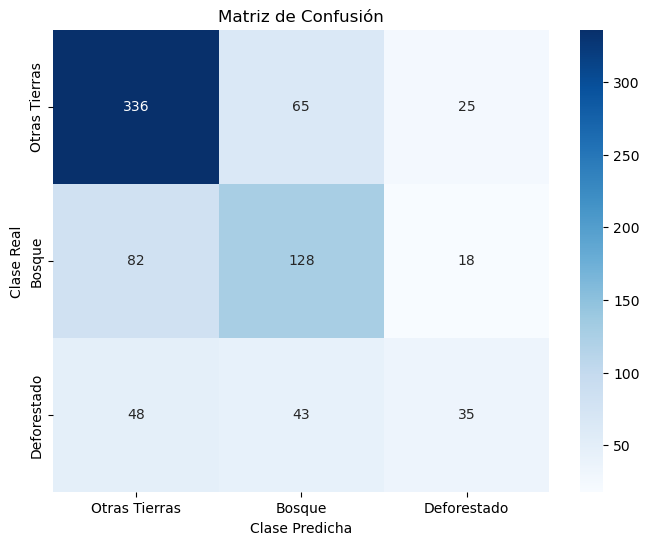

In [26]:
# --- 3. Muestreo Estratificado y Creación del Dataset de Entrenamiento ---

# Definimos la banda que contiene nuestras clases (etiquetas).
# Le cambiaremos el nombre a 'class' por claridad.
class_band = label_image.select('constant').rename('class')

# Unimos las características (features) y la etiqueta (label) en una sola imagen.
# Esto es necesario para que la función de muestreo sepa qué características corresponden a cada etiqueta.
training_image = final_features.addBands(class_band)

# Especificamos el número de "flashcards" (puntos de muestra) que queremos por cada clase.
# Empezaremos con 1,500 por clase. Este es un hiperparámetro que puedes ajustar.
points_per_class = 1500

# Realizamos el muestreo estratificado.
# GEE tomará la imagen, mirará la banda 'class' y se asegurará de recoger
# 1,500 píxeles al azar de la Clase 0, 1,500 de la Clase 1, y 1,500 de la Clase 2.
training_samples = training_image.stratifiedSample(
    numPoints=points_per_class,
    classBand='class',
    projection='EPSG:4326',
    scale=30,
    region=cuenca_aoi,
    geometries=True
).randomColumn()

training_gee = training_samples.filter(ee.Filter.lt('random', 0.7))
testing_gee = training_samples.filter(ee.Filter.gte('random', 0.7))
training_df = geemap.ee_to_df(training_gee)
testing_df = geemap.ee_to_df(testing_gee)
print("Muestreo completado.")

# --- PASO 3: PREPARAR DATOS PARA SKLEARN ---
print("\nPaso 3: Preparando los datos para el modelo...")
features = ['Blue', 'Green', 'Red', 'NIR', 'NDVI']
target = 'class'
training_df.dropna(subset=features + [target], inplace=True)
testing_df.dropna(subset=features + [target], inplace=True)
X_train, y_train = training_df[features], training_df[target]
X_test, y_test = testing_df[features], testing_df[target]
print(f"Datos listos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")

# --- PASO 4: ENTRENAR EL MODELO ---
print("\nPaso 4: Entrenando el modelo RandomForest...")
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
print("¡Modelo entrenado!")

# --- PASO 5: EVALUAR EL MODELO ---
print("\nPaso 5: Evaluando el rendimiento...")
y_pred = classifier.predict(X_test)
report = classification_report(y_test, y_pred, target_names=['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)'])
print("\nReporte de Clasificación:")
print(report)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Otras Tierras', 'Bosque', 'Deforestado'],
            yticklabels=['Otras Tierras', 'Bosque', 'Deforestado'])
plt.title('Matriz de Confusión')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.savefig('confusion_matrix.png')
print("\nMatriz de confusión guardada como 'confusion_matrix.png'")

# --- PASO 6: GUARDAR EL MODELO Y LOS DATOS ---
model_filename = 'deforestation_model_v1.pkl'
joblib.dump(classifier, model_filename)
training_df.to_csv('training_samples.csv', index=False)
testing_df.to_csv('testing_samples.csv', index=False)
print(f"\nPaso 6: ¡PROCESO COMPLETADO! Modelo guardado como '{model_filename}'!")